# Quik SKU Success Prediction — Pre-Listing Model
## Filtered (Availability > 70%) | No Availability | No ROS Features

**Scope:** Predict whether a newly listed SKU will hit its ROS target using only pre-listing signals.  
**Evaluation:** Leave-One-Month-Out (LOMO) — train on 4 months, test on 1, repeat for all 5 months.  
**Models:** Logistic Regression · Random Forest · Gradient Boosting  
**Months:** Jul25 · Sep25 · Oct25 · Nov25 · Dec25

---
### Contents
1. Setup & Data Loading  
2. Feature Engineering  
3. LOMO Evaluation  
4. Results Summary  
5. Month-wise Results  
6. ROC-AUC Curves — all months per model  
7. Feature Importances — all months per model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, roc_curve)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

print("Libraries loaded.")

Libraries loaded.


## 1. Setup & Data Loading

In [2]:
BACKTEST_FILES = {
    'Jul25': "/Users/humair.abbas/Downloads/Jul'25 Backtest.xlsx",
    'Sep25': "/Users/humair.abbas/Downloads/Sep'25 Backtest.xlsx",
    'Oct25': "/Users/humair.abbas/Downloads/Oct'25 Backtest.xlsx",
    'Nov25': "/Users/humair.abbas/Downloads/Nov'25 Backtest.xlsx",
    'Dec25': "/Users/humair.abbas/Downloads/Dec'25 Backtest.xlsx",
}

# Feature set — pre-listing only (formula features + 2 extra signals)
FEATURE_COLS = [
    # ── Formula scores ────────────────────────────────
    'Vel\n Score', 'Vel Floor', 'Benchmark',
    'Sat\n Score', 'Launch\n Score', 'CQ\n SCORE',
    'NMI\n Unit%', 'NMI\n SKU%', 'CH\n SCORE',
    'Return\n Score', 'Mon\n Score', 'SP\n SCORE',
    # ── Engineered formula interactions ───────────────
    'rtv_binary', 'vel_ratio', 'vel_ratio_sq', 'vel_gap', 'above_floor',
    'launch_pct', 'nmi_total', 'nmi_ratio',
    'sat_x_vel', 'cq_x_launch', 'cq_sq', 'rtv_x_mon', 'bench_x_sat',
    'is_width', 'conc_enc', 'asp_enc',
    # ── Two best additional pre-listing signals ────────
    'asp_log',       # higher ASP → harder to hit ROS target (negative signal)
    'subcat_p50mv',  # sub-category market richness (positive signal)
]

MONTHS = list(BACKTEST_FILES.keys())
MONTH_COLORS = {
    'Jul25': '#e6194b', 'Sep25': '#3cb44b',
    'Oct25': '#4363d8', 'Nov25': '#f58231', 'Dec25': '#911eb4'
}
print(f"Feature count: {len(FEATURE_COLS)}")
print(f"Months: {MONTHS}")

Feature count: 30
Months: ['Jul25', 'Sep25', 'Oct25', 'Nov25', 'Dec25']


## 2. Feature Engineering

In [3]:
def load_month(path, month):
    """Load one backtest month and engineer all pre-listing features."""
    # ── Main Working sheet ────────────────────────────────────────────────────
    if month == 'Nov25':
        raw = pd.read_excel(path, sheet_name='Main Working', header=None)
        h   = raw.iloc[6].tolist(); h[0] = 'Barcode'
        df  = raw.iloc[7:].copy()
        df.columns = [str(x).strip() for x in h]
        cnt = Counter(); nc = []
        for c in df.columns:
            cnt[c] += 1
            nc.append(f"{c}.dup{cnt[c]-1}" if cnt[c] > 1 else c)
        df.columns = nc
    elif month == 'Dec25':
        df = pd.read_excel(path, sheet_name='Main Working', header=5)
        df.columns = [str(c).strip() for c in df.columns]
    else:
        df = pd.read_excel(path, sheet_name='Main Working', header=4)
        df.columns = [str(c).strip() for c in df.columns]

    df['month']        = month
    df['Success']      = pd.to_numeric(df['Success'],      errors='coerce')
    df['Availability'] = pd.to_numeric(df.get('Availability', np.nan), errors='coerce')

    # ── Reference Data (peer ROS signals) ────────────────────────────────────
    ref = pd.read_excel(path, sheet_name='Refrence Data', header=0)
    ref.columns = [str(c).strip() for c in ref.columns]
    ref = ref.drop_duplicates('Subcat_ASP Key', keep='first')
    for c in ref.select_dtypes(include='number').columns:
        ref[c] = pd.to_numeric(ref[c], errors='coerce').fillna(0)
    ref_d = ref.set_index('Subcat_ASP Key').to_dict('index')

    # ── New Launch Success Rate ────────────────────────────────────────────────
    nl = pd.read_excel(path, sheet_name='New Launch Success Rate', header=0)
    nl.columns = [str(c).strip() for c in nl.columns]
    nl['Total New Launches (Last 180d)'] = pd.to_numeric(
        nl['Total New Launches (Last 180d)'], errors='coerce').fillna(0)
    nl = nl.drop_duplicates('Subcat_ASP Bucket', keep='first').set_index('Subcat_ASP Bucket')

    # ── Non Moving ───────────────────────────────────────────────────────────
    nm = pd.read_excel(path, sheet_name='Non Moving', header=0)
    nm.columns = [str(c).strip() for c in nm.columns]
    for c in ['non_moving_sku_pct', 'non_moving_onhand_pct']:
        nm[c] = pd.to_numeric(nm[c], errors='coerce').fillna(0)
    nm = nm.drop_duplicates('Concat', keep='first').set_index('Concat')

    # ── Keys ─────────────────────────────────────────────────────────────────
    keys    = df['Subcat ASP Key'].fillna('').astype(str).str.strip()
    sc_col  = next((c for c in df.columns if 'subcateg' in c.lower()), None)
    asp_col = next((c for c in df.columns if c.lower().startswith('asp') and 'bucket' in c.lower()), None)
    nm_keys = (df[sc_col].fillna('').astype(str).str.strip() + '_' +
               df[asp_col].fillna('').astype(str).str.strip()) if sc_col and asp_col else pd.Series('', index=df.index)

    def vc(col, fb=0.0):
        return np.array([float(ref_d.get(k, {}).get(col, fb) or fb) for k in keys])

    # ── Formula scores ────────────────────────────────────────────────────────
    for col in ['Vel\n Score', 'Vel Floor', 'Benchmark', 'Sat\n Score',
                'Launch\n Score', 'CQ\n SCORE', 'NMI\n Unit%', 'NMI\n SKU%',
                'CH\n SCORE', 'Return\n Score', 'Mon\n Score', 'SP\n SCORE',
                'Launch Success\n %']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0) if col in df.columns else 0.0

    # ── Engineered interactions ───────────────────────────────────────────────
    df['rtv_binary']  = (df.get('RTV Terms', pd.Series('')).astype(str).str.lower() == 'yes').astype(int)
    vfn               = df['Vel Floor'].replace(0, np.nan)
    df['vel_ratio']   = (df['Benchmark'] / vfn).clip(0, 5).fillna(0)
    df['vel_ratio_sq']= df['vel_ratio'] ** 2
    df['vel_gap']     = (df['Benchmark'] - df['Vel Floor']).fillna(0)
    df['above_floor'] = (df['Benchmark'] >= df['Vel Floor']).astype(int)
    df['launch_pct']  = df['Launch Success\n %']
    df['nmi_total']   = df['NMI\n Unit%'] + df['NMI\n SKU%']
    df['nmi_ratio']   = (df['NMI\n Unit%'] / df['NMI\n SKU%'].replace(0, np.nan)).clip(0, 10).fillna(0)
    df['sat_x_vel']   = df['Sat\n Score']  * df['Vel\n Score']  / 10000
    df['cq_x_launch'] = df['CQ\n SCORE']   * (df['Launch\n Score'] > 0).astype(int)
    df['cq_sq']       = (df['CQ\n SCORE']  / 100) ** 2
    df['rtv_x_mon']   = df['rtv_binary']   * df['Mon\n Score']
    df['bench_x_sat'] = df['Benchmark']    * df['Sat\n Score'] / 10000
    df['is_width']    = (df.get('Width or Depth', pd.Series('Depth', index=df.index)) == 'Width').astype(int)
    df['conc_enc']    = df.get('Conc\n Level', pd.Series('MEDIUM', index=df.index)).map(
                            {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}).fillna(1).astype(int)
    df['asp_enc']     = df.get('ASP\n Bucket', pd.Series('25+', index=df.index)).map(
                            {'0-5':0,'5-10':1,'10-15':2,'15-20':3,'20-25':4,'25+':5}).fillna(5).astype(int)

    # ── SKU-level signals ─────────────────────────────────────────────────────
    df['asp_log']  = np.log1p(pd.to_numeric(df.get('ASP', 0), errors='coerce').fillna(0).clip(0, 500))

    # ── Peer ROS from Reference Data ──────────────────────────────────────────
    df['p10_mv']       = vc('P10 ROS (Moving)')
    df['p50_mv']       = vc('P50 ROS (Moving)')
    df['subcat_p50mv'] = vc('Sub Category P50 ROS (Moving)')

    # ── Launch signals ────────────────────────────────────────────────────────
    df['launch_n']  = [float(nl.loc[k, 'Total New Launches (Last 180d)'])
                       if k in nl.index else 0 for k in keys]
    df['launch_conf'] = np.array(df['launch_n']) / (np.array(df['launch_n']) + 10)

    # ── Non-moving granular ───────────────────────────────────────────────────
    df['nm_sku_pct'] = [float(nm.loc[k, 'non_moving_sku_pct'])    if k in nm.index else 50 for k in nm_keys]
    df['nm_inv_pct'] = [float(nm.loc[k, 'non_moving_onhand_pct']) if k in nm.index else 50 for k in nm_keys]

    return df


print("Loading all 5 months (Avail > 70% filter applied)...")
dfs  = [load_month(p, m) for m, p in BACKTEST_FILES.items()]
data = pd.concat(dfs, ignore_index=True)
data = data[data['Success'].isin([0.0, 1.0])].copy()
data['Success'] = data['Success'].astype(int)
data = data[data['Availability'] > 0.70].copy()
data = data.reset_index(drop=True)

print(f"\nTotal rows after filter : {len(data)}")
print(f"Class balance           : {dict(data['Success'].value_counts().sort_index())}")
print(f"\nRows & success rate by month:")
print(data.groupby('month')['Success'].agg(['count','mean'])
      .rename(columns={'mean':'success_rate'}).round(3).to_string())

Loading all 5 months (Avail > 70% filter applied)...

Total rows after filter : 791
Class balance           : {0: np.int64(422), 1: np.int64(369)}

Rows & success rate by month:
       count  success_rate
month                     
Dec25    136         0.331
Jul25    127         0.354
Nov25    136         0.551
Oct25    170         0.447
Sep25    222         0.577


## 3. LOMO Evaluation

In [4]:
# ── Model definitions ─────────────────────────────────────────────────────────
MODELS = {
    'Logistic Regression': {
        'fn':    lambda: LogisticRegression(max_iter=3000, C=0.1, penalty='l2',
                                             solver='lbfgs', class_weight='balanced',
                                             random_state=42),
        'scale': True,
        'color': '#e6194b',
    },
    'Random Forest': {
        'fn':    lambda: RandomForestClassifier(n_estimators=600, max_depth=4,
                                                 min_samples_leaf=2, max_features='log2',
                                                 class_weight='balanced',
                                                 random_state=42, n_jobs=-1),
        'scale': False,
        'color': '#3cb44b',
    },
    'Gradient Boosting': {
        'fn':    lambda: GradientBoostingClassifier(n_estimators=400, max_depth=3,
                                                     learning_rate=0.01, subsample=0.8,
                                                     min_samples_leaf=10, random_state=42),
        'scale': False,
        'color': '#4363d8',
    },
}

months_list = sorted(data['month'].unique())

# ── Run LOMO ──────────────────────────────────────────────────────────────────
lomo_metrics   = {}   # mname -> DataFrame(Month, N, Acc, Prec, Rec, AUC, F1)
lomo_roc       = {}   # mname -> {month -> (fpr, tpr, auc)}
lomo_feat_imp  = {}   # mname -> {month -> Series(feature -> importance)}

for mname, mcfg in MODELS.items():
    rows  = []
    rocs  = {}
    fimps = {}

    for tm in months_list:
        tr_mask = data['month'] != tm
        te_mask = data['month'] == tm
        X = data[FEATURE_COLS].fillna(0)
        y = data['Success']

        sc  = StandardScaler()
        Xtr = sc.fit_transform(X[tr_mask]) if mcfg['scale'] else X[tr_mask].values
        Xte = sc.transform(X[te_mask])     if mcfg['scale'] else X[te_mask].values

        model = mcfg['fn']()
        model.fit(Xtr, y[tr_mask])
        proba = model.predict_proba(Xte)[:, 1]
        preds = (proba >= 0.5).astype(int)

        # metrics
        rows.append({
            'Month':     tm,
            'N':         int(te_mask.sum()),
            'Accuracy':  round(accuracy_score(y[te_mask], preds), 4),
            'Precision': round(precision_score(y[te_mask], preds, zero_division=0), 4),
            'Recall':    round(recall_score(y[te_mask], preds, zero_division=0), 4),
            'AUC':       round(roc_auc_score(y[te_mask], proba), 4),
            'F1':        round(f1_score(y[te_mask], preds, zero_division=0), 4),
        })

        # ROC curve
        fpr, tpr, _ = roc_curve(y[te_mask], proba)
        rocs[tm]    = (fpr, tpr, roc_auc_score(y[te_mask], proba))

        # Feature importance
        if hasattr(model, 'coef_'):
            imp = pd.Series(np.abs(model.coef_[0]), index=FEATURE_COLS)
        else:
            imp = pd.Series(model.feature_importances_, index=FEATURE_COLS)
        fimps[tm] = imp

    lomo_metrics[mname]  = pd.DataFrame(rows)
    lomo_roc[mname]      = rocs
    lomo_feat_imp[mname] = fimps

print("LOMO complete.")
for mname, df_r in lomo_metrics.items():
    print(f"  {mname:<22} Acc={df_r['Accuracy'].mean():.4f} ±{df_r['Accuracy'].std():.3f}"
          f"  AUC={df_r['AUC'].mean():.4f}")

LOMO complete.
  Logistic Regression    Acc=0.6933 ±0.022  AUC=0.7550
  Random Forest          Acc=0.6869 ±0.033  AUC=0.7375
  Gradient Boosting      Acc=0.6497 ±0.075  AUC=0.7432


## 4. Results Summary

══ Overall LOMO Summary (mean ± std across 5 months) ══════════════════════════
Model                      Acc      ±     AUC    Prec     Rec      F1
──────────────────────────────────────────────────────────────
Logistic Regression    0.6933  ±0.022  0.7550  0.6376  0.7272  0.6741
Random Forest          0.6869  ±0.033  0.7375  0.6372  0.7416  0.6722
Gradient Boosting      0.6497  ±0.075  0.7432  0.6347  0.6179  0.5931


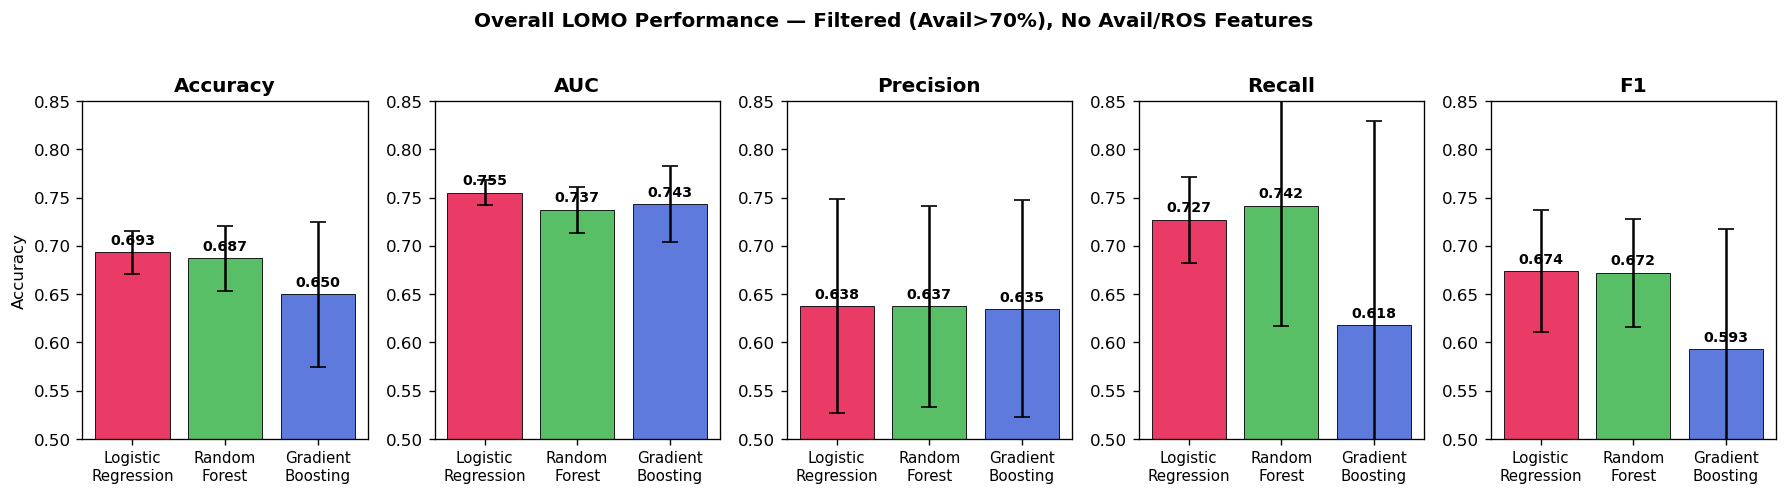

In [5]:
# ── Overall summary table ────────────────────────────────────────────────────
print("══ Overall LOMO Summary (mean ± std across 5 months) ══════════════════════════")
print(f"{'Model':<22} {'Acc':>7}  {'±':>5}  {'AUC':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}")
print("─" * 62)
for mname, df_r in lomo_metrics.items():
    print(f"{mname:<22} {df_r['Accuracy'].mean():.4f}  "
          f"±{df_r['Accuracy'].std():.3f}  "
          f"{df_r['AUC'].mean():.4f}  "
          f"{df_r['Precision'].mean():.4f}  "
          f"{df_r['Recall'].mean():.4f}  "
          f"{df_r['F1'].mean():.4f}")

# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_show = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1']
fig, axes = plt.subplots(1, len(metrics_show), figsize=(15, 4), sharey=False)

for ax, metric in zip(axes, metrics_show):
    vals   = [lomo_metrics[m][metric].mean() for m in MODELS]
    errs   = [lomo_metrics[m][metric].std()  for m in MODELS]
    colors = [MODELS[m]['color'] for m in MODELS]
    bars   = ax.bar(list(MODELS.keys()), vals, yerr=errs, color=colors,
                    capsize=5, alpha=0.85, edgecolor='black', linewidth=0.6)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0.50, 0.85)
    ax.set_xticklabels([m.replace(' ', '\n') for m in MODELS], fontsize=9)
    ax.set_ylabel(metric if ax == axes[0] else '')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

fig.suptitle('Overall LOMO Performance — Filtered (Avail>70%), No Avail/ROS Features',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/humair.abbas/Downloads/summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Month-wise Results


── Logistic Regression ──────────────────────────────────────────────
         N  Accuracy     AUC  Precision  Recall      F1
Month                                                  
Dec25  136    0.6765  0.7536     0.5079  0.7111  0.5926
Jul25  127    0.6772  0.7524     0.5312  0.7556  0.6239
Nov25  136    0.6985  0.7353     0.7024  0.7867  0.7421
Oct25  170    0.7294  0.7643     0.6923  0.7105  0.7013
Sep25  222    0.6847  0.7694     0.7544  0.6719  0.7107
MEAN     —    0.6933  0.7550     0.6376  0.7272  0.6741
STD      —    0.0221  0.0131     0.1107  0.0446  0.0630

── Random Forest ──────────────────────────────────────────────
         N  Accuracy     AUC  Precision  Recall      F1
Month                                                  
Dec25  136    0.6765  0.7184     0.5068  0.8222  0.6271
Jul25  127    0.7008  0.7291     0.5556  0.7778  0.6481
Nov25  136    0.6985  0.7308     0.6848  0.8400  0.7545
Oct25  170    0.7235  0.7792     0.6747  0.7368  0.7044
Sep25  222    0.6351  0.

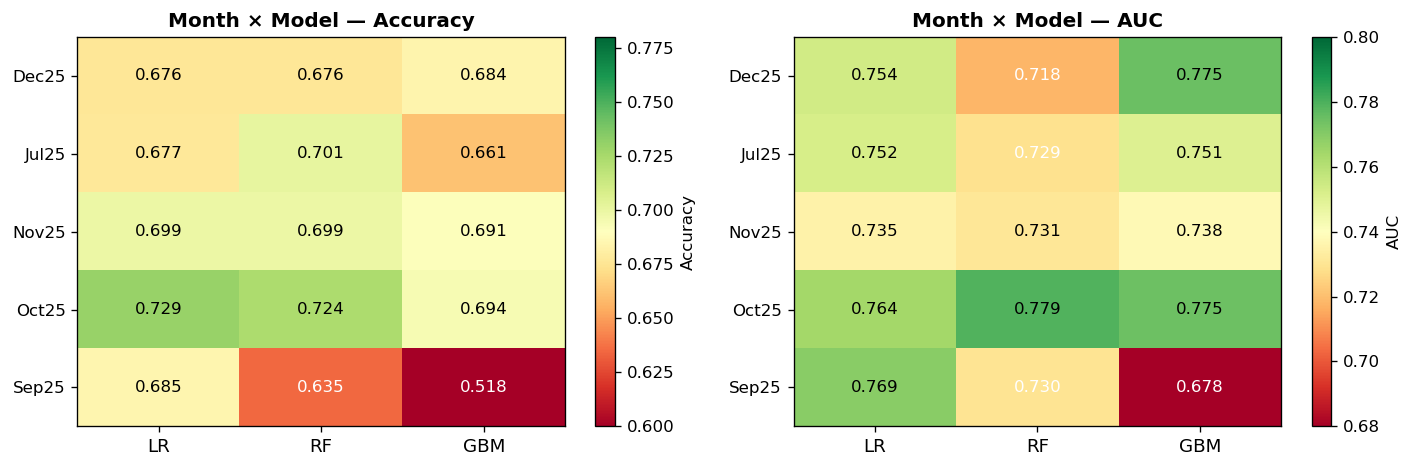

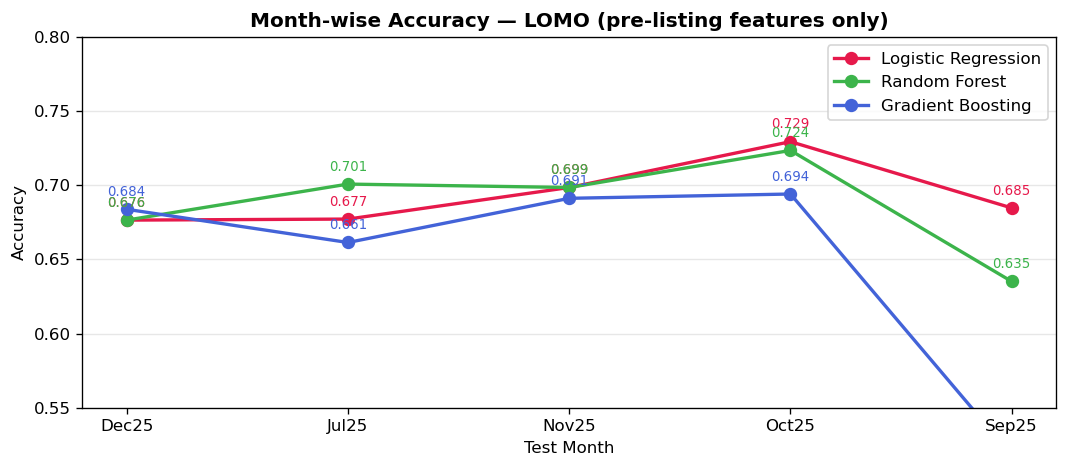

In [6]:
# ── Per-model month-wise tables ──────────────────────────────────────────────
for mname, df_r in lomo_metrics.items():
    print(f"\n── {mname} ──────────────────────────────────────────────")
    display_df = df_r.set_index('Month')[['N','Accuracy','AUC','Precision','Recall','F1']].copy()
    display_df.loc['MEAN'] = ['—'] + [round(df_r[c].mean(),4) for c in ['Accuracy','AUC','Precision','Recall','F1']]
    display_df.loc['STD']  = ['—'] + [round(df_r[c].std(), 4) for c in ['Accuracy','AUC','Precision','Recall','F1']]
    print(display_df.to_string())

# ── Heatmap — Accuracy across models × months ────────────────────────────────
model_names = list(MODELS.keys())
acc_mat = np.array([[lomo_metrics[m].set_index('Month').loc[mo, 'Accuracy']
                     for m in model_names] for mo in months_list])
auc_mat = np.array([[lomo_metrics[m].set_index('Month').loc[mo, 'AUC']
                     for m in model_names] for mo in months_list])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
short_names = ['LR', 'RF', 'GBM']

for ax, mat, title, vmin, vmax in zip(
    axes,
    [acc_mat, auc_mat],
    ['Accuracy', 'AUC'],
    [0.60, 0.68],
    [0.78, 0.80]
):
    im = ax.imshow(mat, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(short_names, fontsize=11)
    ax.set_yticks(range(len(months_list))); ax.set_yticklabels(months_list)
    for i, mo in enumerate(months_list):
        for j, mn in enumerate(model_names):
            v = mat[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=10,
                    color='black' if vmin + 0.05 < v < vmax - 0.02 else 'white')
    plt.colorbar(im, ax=ax, label=title)
    ax.set_title(f'Month × Model — {title}', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/humair.abbas/Downloads/monthwise_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Line chart — Accuracy per month ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(months_list))
for mname, mcfg in MODELS.items():
    accs = lomo_metrics[mname].set_index('Month').loc[months_list, 'Accuracy'].values
    ax.plot(x, accs, 'o-', color=mcfg['color'], label=mname, linewidth=2, markersize=7)
    for xi, v in zip(x, accs):
        ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color=mcfg['color'])

ax.set_xticks(x); ax.set_xticklabels(months_list)
ax.set_ylim(0.55, 0.80); ax.set_ylabel('Accuracy'); ax.set_xlabel('Test Month')
ax.set_title('Month-wise Accuracy — LOMO (pre-listing features only)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/humair.abbas/Downloads/monthwise_accuracy_line.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC-AUC Curves — All Months per Model

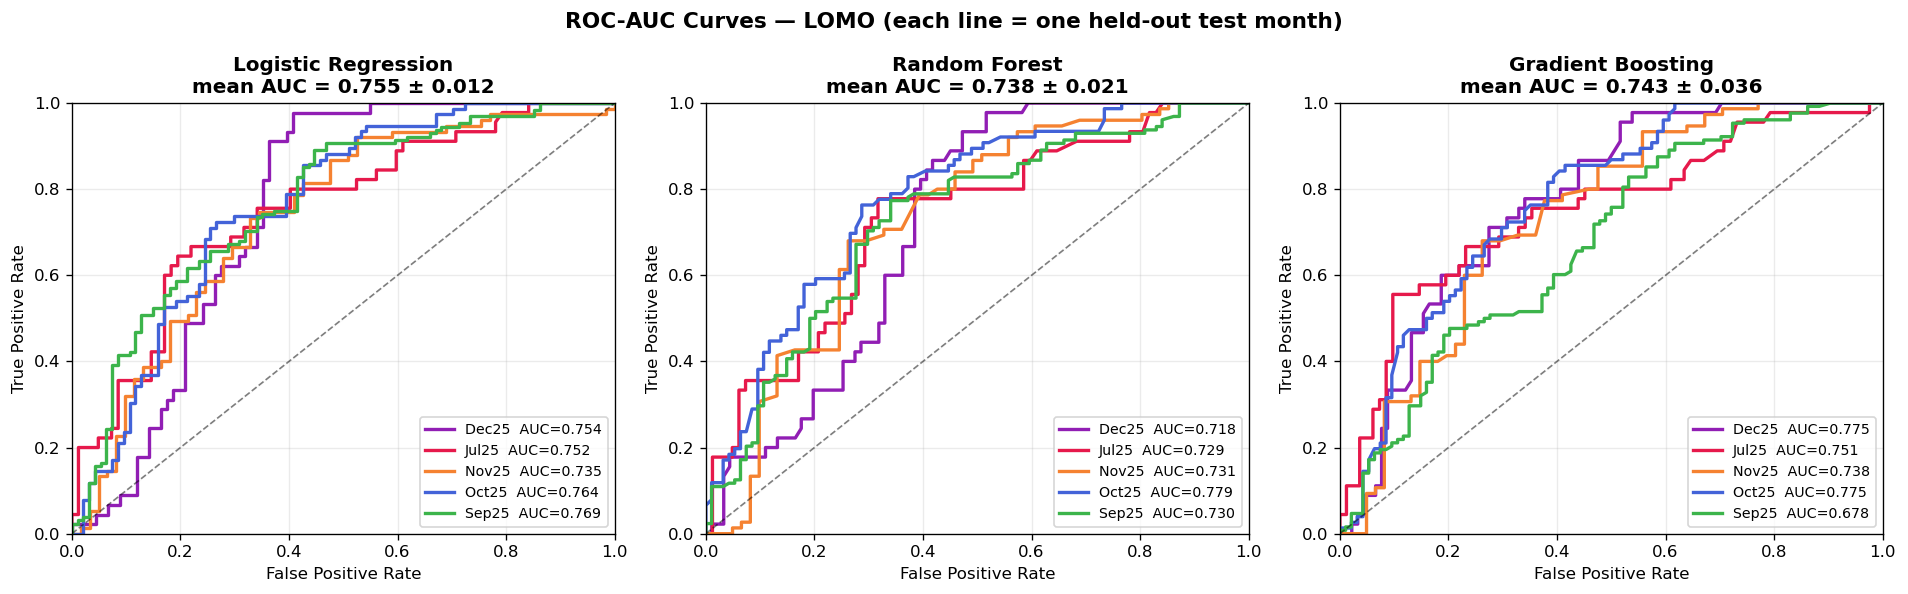


── AUC Values per Month ─────────────────────────────────────────────────────
           LR      RF     GBM
Month                        
Dec25  0.7536  0.7184  0.7747
Jul25  0.7524  0.7291  0.7507
Nov25  0.7353  0.7308  0.7377
Oct25  0.7643  0.7792  0.7746
Sep25  0.7694  0.7299  0.6781
MEAN   0.7550  0.7375  0.7432
STD    0.0131  0.0239  0.0397


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (mname, mcfg) in zip(axes, MODELS.items()):
    auc_vals = []
    for mo in months_list:
        fpr, tpr, auc_val = lomo_roc[mname][mo]
        ax.plot(fpr, tpr, color=MONTH_COLORS[mo], linewidth=2,
                label=f'{mo}  AUC={auc_val:.3f}')
        auc_vals.append(auc_val)

    # Mean ROC (micro-average approach — diagonal reference)
    ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{mname}\nmean AUC = {np.mean(auc_vals):.3f} ± {np.std(auc_vals):.3f}',
                 fontweight='bold')
    ax.legend(loc='lower right', fontsize=8.5)
    ax.grid(alpha=0.25)
    # Shade region
    ax.fill_between([0,1],[0,1],[0,1], alpha=0.04, color='grey')

fig.suptitle('ROC-AUC Curves — LOMO (each line = one held-out test month)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/humair.abbas/Downloads/roc_curves_all_months.png', dpi=150, bbox_inches='tight')
plt.show()

# ── AUC value table ───────────────────────────────────────────────────────────
print("\n── AUC Values per Month ─────────────────────────────────────────────────────")
auc_rows = {mo: {mname: round(lomo_roc[mname][mo][2], 4)
                 for mname in MODELS} for mo in months_list}
auc_df = pd.DataFrame(auc_rows).T
auc_df.index.name = 'Month'
auc_df.columns = ['LR', 'RF', 'GBM']
auc_df.loc['MEAN'] = auc_df.mean().round(4)
auc_df.loc['STD']  = auc_df.iloc[:-1].std().round(4)
print(auc_df.to_string())

## 7. Feature Importances — All Months per Model

- **Logistic Regression** — absolute coefficient magnitude (scaled features)  
- **Random Forest / Gradient Boosting** — mean decrease in impurity (MDI)  

Each subplot shows importances trained on 4 months (the training fold for that test month).


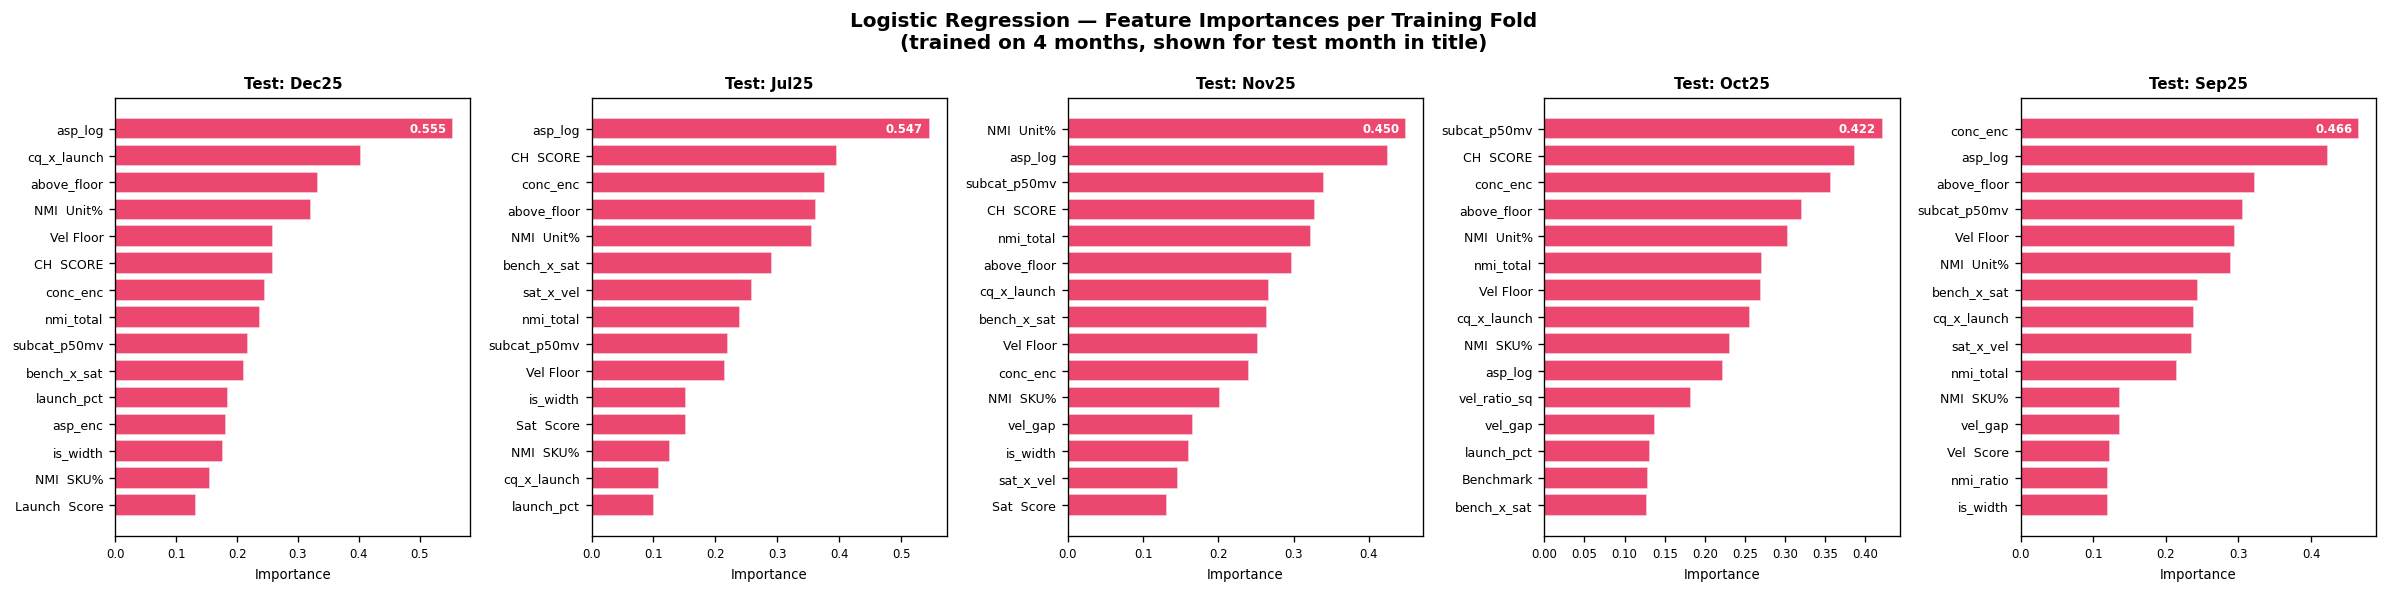

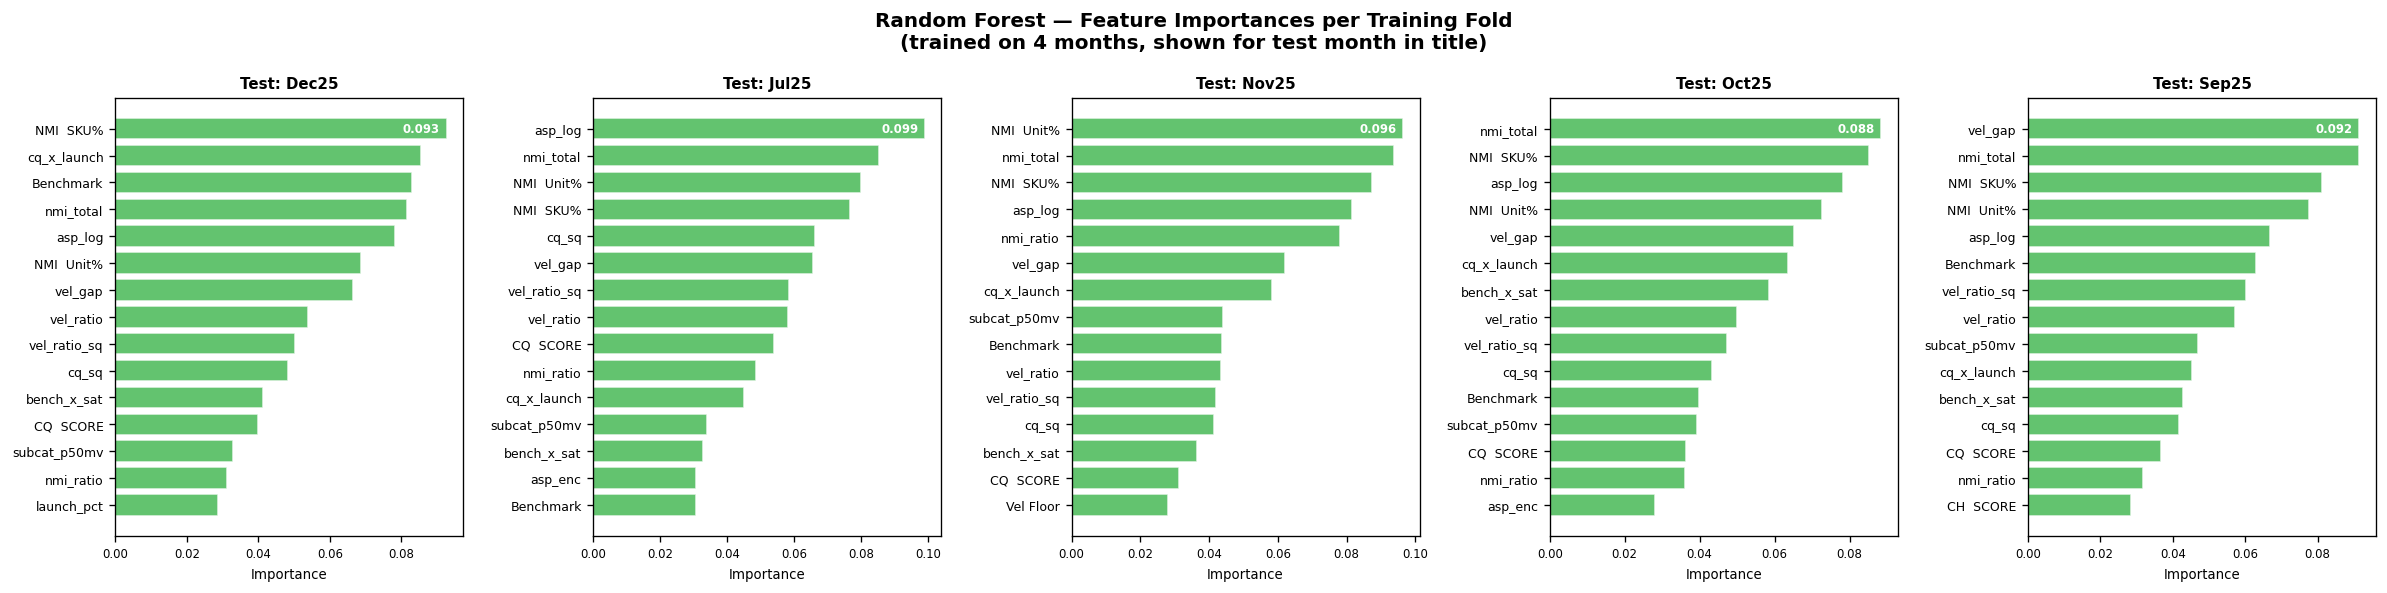

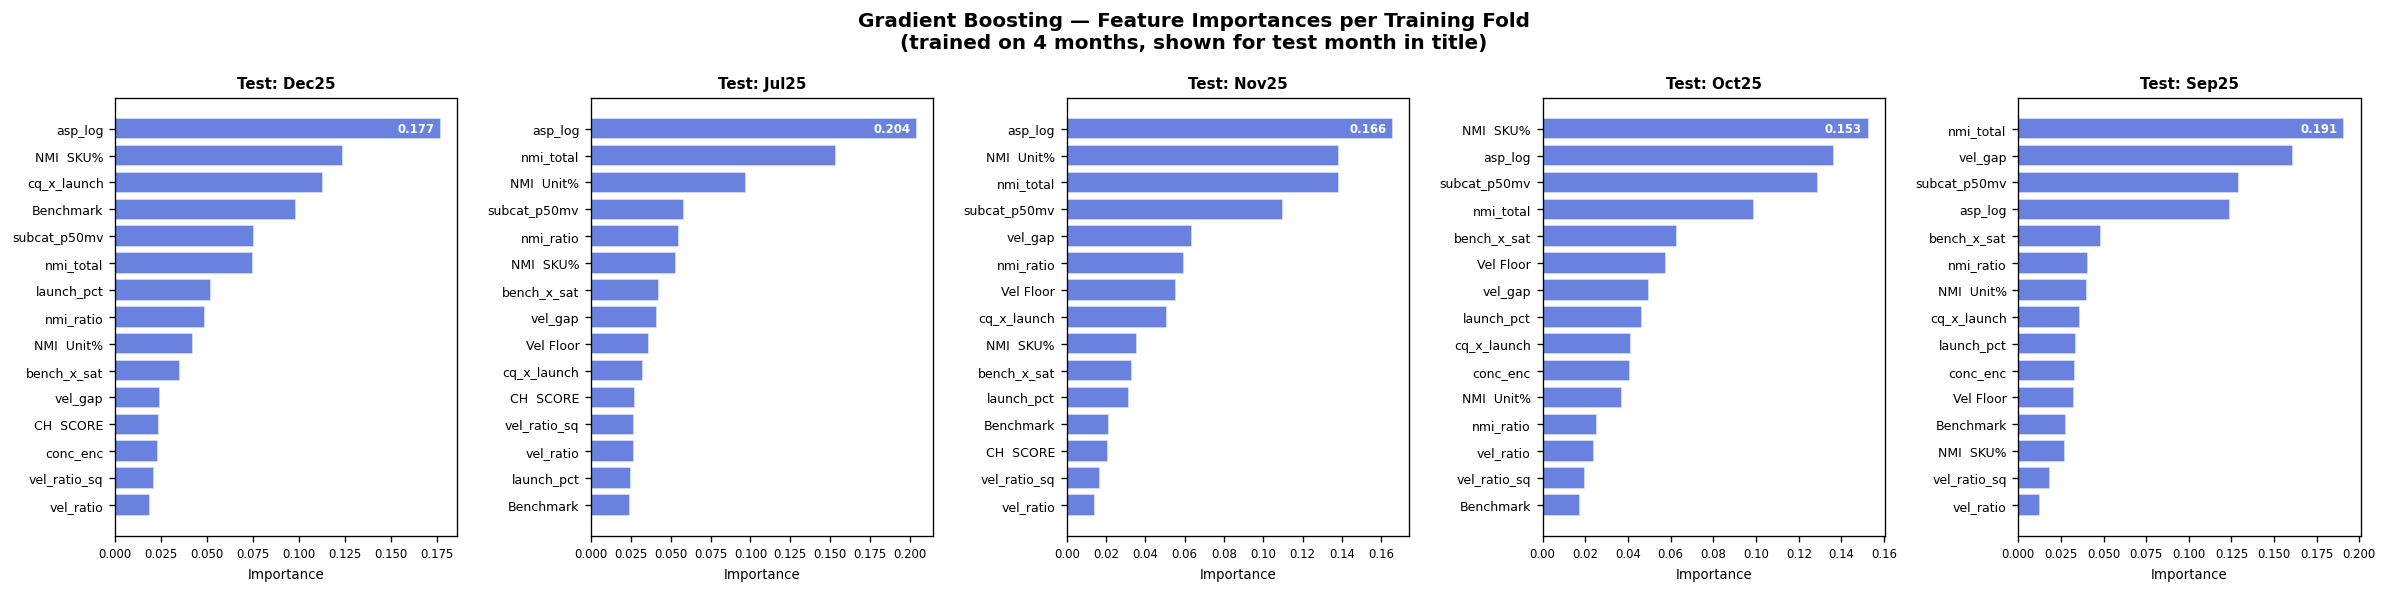


── Feature importance stability (mean rank across all folds) ─────────────────

  Logistic Regression — top 10 most consistently important features:
    asp_log                        avg rank = 3.2
    above_floor                    avg rank = 4.0
    NMI  Unit%                     avg rank = 4.2
    conc_enc                       avg rank = 4.8
    subcat_p50mv                   avg rank = 5.2
    CH  SCORE                      avg rank = 6.6
    Vel Floor                      avg rank = 7.2
    nmi_total                      avg rank = 7.4
    cq_x_launch                    avg rank = 7.8
    bench_x_sat                    avg rank = 9.2

  Random Forest — top 10 most consistently important features:
    nmi_total                      avg rank = 2.2
    NMI  SKU%                      avg rank = 2.6
    asp_log                        avg rank = 3.6
    NMI  Unit%                     avg rank = 3.6
    vel_gap                        avg rank = 5.0
    cq_x_launch                    a

In [9]:
# ── Per-model: subplot grid — one bar chart per month ────────────────────────
for mname, mcfg in MODELS.items():
    fig, axes = plt.subplots(1, len(months_list), figsize=(20, 5), sharey=False)
    fig.suptitle(f'{mname} — Feature Importances per Training Fold\n'
                 f'(trained on 4 months, shown for test month in title)',
                 fontsize=12, fontweight='bold')

    for ax, mo in zip(axes, months_list):
        imp = lomo_feat_imp[mname][mo].sort_values(ascending=False).head(15)
        # Shorten feature names for display
        short = imp.index.str.replace('\\n ', '\n').str.replace('\n', ' ').str.strip()
        bars = ax.barh(range(len(imp)), imp.values, color=mcfg['color'], alpha=0.8, edgecolor='white')
        ax.set_yticks(range(len(imp))); ax.set_yticklabels(short, fontsize=7.5)
        ax.invert_yaxis()
        ax.set_title(f'Test: {mo}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Importance', fontsize=8)
        ax.tick_params(axis='x', labelsize=7)
        # Annotate top bar
        ax.text(imp.values[0] * 0.98, 0, f'{imp.values[0]:.3f}',
                va='center', ha='right', fontsize=7, color='white', fontweight='bold')

    plt.tight_layout()
    safe = mname.lower().replace(' ', '_')
    plt.savefig(f'/Users/humair.abbas/Downloads/feat_imp_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Stability: how consistent are the top features across folds? ───────────────
print("\n── Feature importance stability (mean rank across all folds) ─────────────────")
for mname in MODELS:
    ranks = {}
    for mo in months_list:
        imp = lomo_feat_imp[mname][mo].sort_values(ascending=False)
        for rank, feat in enumerate(imp.index, 1):
            ranks.setdefault(feat, []).append(rank)
    mean_ranks = pd.Series({f: np.mean(r) for f, r in ranks.items()}).sort_values()
    short_index = mean_ranks.index.str.replace('\\n ', ' ').str.replace('\n', ' ').str.strip()
    print(f"\n  {mname} — top 10 most consistently important features:")
    for feat, mr in zip(short_index[:10], mean_ranks.head(10)):
        print(f"    {feat:<30} avg rank = {mr:.1f}")

### 7b. Feature Importance Heatmap — Top 15 features × 5 months

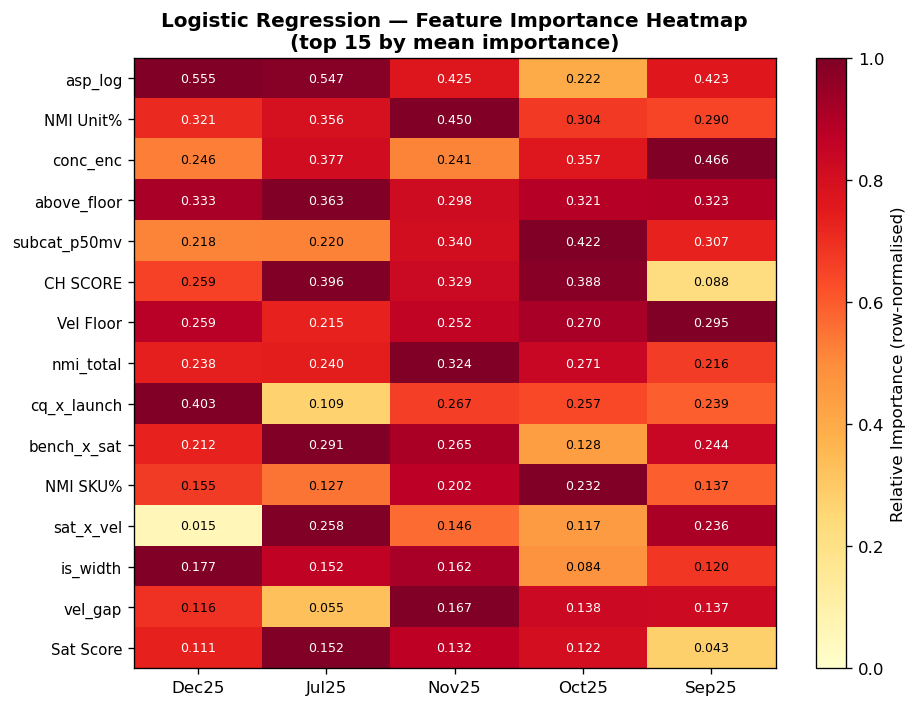

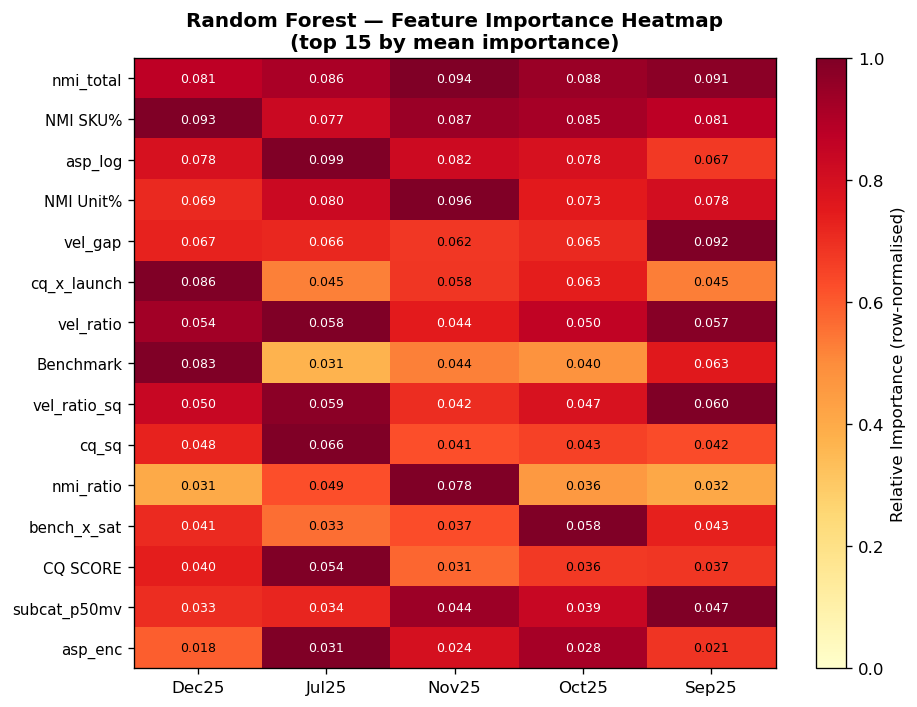

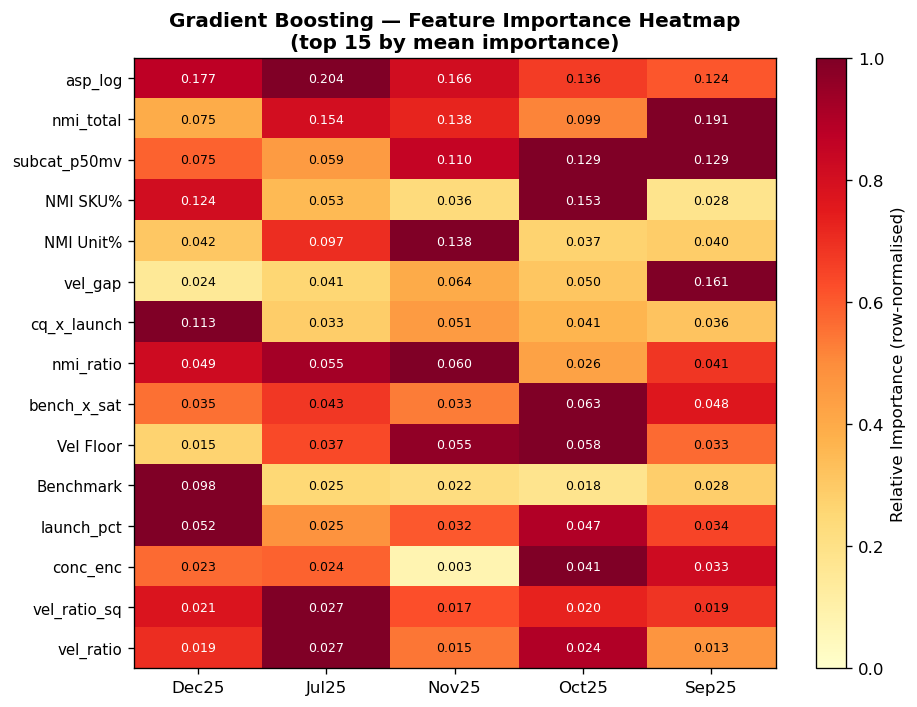

In [10]:
for mname, mcfg in MODELS.items():
    # Build matrix: top 15 features (by mean importance) × months
    all_imp = pd.DataFrame({mo: lomo_feat_imp[mname][mo] for mo in months_list})
    top15   = all_imp.mean(axis=1).sort_values(ascending=False).head(15).index
    mat     = all_imp.loc[top15].values
    # Normalise each feature row to [0,1] for visual comparison
    row_max = mat.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1
    mat_norm = mat / row_max

    short_labels = [f.replace('\n ', ' ').replace('\n', ' ').strip() for f in top15]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(mat_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(months_list))); ax.set_xticklabels(months_list, fontsize=10)
    ax.set_yticks(range(len(top15)));       ax.set_yticklabels(short_labels, fontsize=9)
    for i in range(len(top15)):
        for j in range(len(months_list)):
            ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center',
                    fontsize=7.5, color='black' if mat_norm[i,j] < 0.7 else 'white')
    plt.colorbar(im, ax=ax, label='Relative Importance (row-normalised)')
    ax.set_title(f'{mname} — Feature Importance Heatmap\n(top 15 by mean importance)',
                 fontweight='bold')
    plt.tight_layout()
    safe = mname.lower().replace(' ', '_')
    plt.savefig(f'/Users/humair.abbas/Downloads/feat_heatmap_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()